In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [ ]:
def load_evidence(fn, ds_name):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    df["ds_name"] = ds_name
    ddf = df['derived'].apply(pd.Series)

    # normalize the string values for cell types
    ddf["cell_type_label"] = ddf["cell_type_label"].str.strip().str.upper()
    ddf["cell_type_id"] = ddf["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    ddf["feature_name"] = ddf["feature_name"].str.strip().str.upper()
    ddf["feature_identifier"] = ddf["feature_identifier"].str.strip().str.upper()
    hddf = ddf.query("organism == 'homo_sapiens'").dropna(subset=["feature_identifier"])
    return hddf

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [ ]:
# ds = "adipose_Hildreth2021"
# ds = "adipose_Vijay2019"

ds = "adipose_Hildreth2021"
fn_hmn   = f"../../data/{ds}/evidence_human/evidence.json"
ctmap_fn = f"../../data/{ds}/ctmap.json"

hmn = load_evidence(fn_hmn, ds)
ctmap, rev_ctmap = get_ctmap(ctmap_fn)
hmn["cell_type_id"] = hmn["cell_type_label"].map(lambda x: rev_ctmap[x])

ds = "adipose_Vijay2019"
fn_deg   = f"../../data/{ds}/evidence_human/evidence.json"
ctmap_fn = f"../../data/{ds}/ctmap.json"

deg = load_evidence(fn_deg, ds)
ctmap, rev_ctmap = get_ctmap(ctmap_fn)
deg["cell_type_id"] = deg["cell_type_label"].map(lambda x: rev_ctmap[x])

## Global Gene and Celltype comparisons

In [203]:
feature = "feature_identifier" # <-- to use once we fill in the id from the gene name
# feature = "feature_name"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (feature_identifier)
	left	itx	right
raw	72	12	55
norm	0.52	0.09	0.40


In [204]:
lv

array(['ENSG00000010610', 'ENSG00000017427', 'ENSG00000072694',
       'ENSG00000073861', 'ENSG00000075618', 'ENSG00000078081',
       'ENSG00000078401', 'ENSG00000095970', 'ENSG00000099985',
       'ENSG00000100311', 'ENSG00000102524', 'ENSG00000102962',
       'ENSG00000102970', 'ENSG00000107485', 'ENSG00000107562',
       'ENSG00000108691', 'ENSG00000112486', 'ENSG00000112715',
       'ENSG00000113088', 'ENSG00000115594', 'ENSG00000115602',
       'ENSG00000115904', 'ENSG00000116824', 'ENSG00000118785',
       'ENSG00000119535', 'ENSG00000120659', 'ENSG00000125347',
       'ENSG00000125378', 'ENSG00000125657', 'ENSG00000125845',
       'ENSG00000126353', 'ENSG00000128342', 'ENSG00000128815',
       'ENSG00000132514', 'ENSG00000134545', 'ENSG00000136244',
       'ENSG00000137265', 'ENSG00000137801', 'ENSG00000140968',
       'ENSG00000149294', 'ENSG00000150045', 'ENSG00000150782',
       'ENSG00000153563', 'ENSG00000157404', 'ENSG00000158481',
       'ENSG00000162594', 'ENSG000001627

In [205]:
# feature = "cell_type_label" # eventually change this to comparing based on a map we can create
feature = "cell_type_id"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (cell_type_id)
	left	itx	right
raw	6	5	10
norm	0.29	0.24	0.48


In [206]:
# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])



In [207]:
df

Feature        cell_type_id                     feature_name             \
Set Comparison         left       itx     right         left        itx   
raw                6.000000  5.000000  10.00000    72.000000  12.000000   
norm               0.285714  0.238095   0.47619     0.517986   0.086331   

Feature                    
Set Comparison      right  
raw             55.000000  
norm             0.395683

## Cell-type-specific comparisons

In [208]:
def ctg_metric(df1, df2, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True):
    # common cell types
    common_ct = np.intersect1d(df1[ct_col].unique(), df2[ct_col].unique())
    common_gn = np.intersect1d(df1[gene_col].unique(), df2[gene_col].unique())


    # comm_df1 = df1[df1[ct_col].isin(common_ct)]
    # comm_df2 = df2[df2[ct_col].isin(common_ct)]
    
    # here we filter for the same set of cell types and genes <-- note we may want to change this!
    if comm_ct and not comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct)]
        comm_df2 = df2[df2[ct_col].isin(common_ct)]
    elif comm_gene and not comm_ct:
        comm_df1 = df1[df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[gene_col].isin(common_gn)]
    elif comm_ct and comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct) & df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[ct_col].isin(common_ct) & df2[gene_col].isin(common_gn)]
    else:
        comm_df1 = df1
        comm_df2 = df2

    df1_ctg_list = comm_df1.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df1_ctg_list = df1_ctg_list.reindex(common_ct, fill_value=[])
    df2_ctg_list = comm_df2.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df2_ctg_list = df2_ctg_list.reindex(common_ct, fill_value=[])

    # now take the left set diff, intersection, and right set diff for every pair of cell types in the two dataframes
    ctg_cmp = {}
    ctg_cmp_vals = {}
    for ct1 in df1_ctg_list.index:
        for ct2 in df2_ctg_list.index:
            l, x, r  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2])
            lv, xv, rv  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2], vals=True)
            ctg_cmp[(ct1, ct2)] = (l, x, r)
            ctg_cmp_vals[(ct1, ct1)] = (lv, xv, rv)

    pvt = pd.DataFrame(ctg_cmp.values(), index=ctg_cmp.keys(), columns=["l", "x", "r"]).reset_index(names=[df1_label, df2_label]).pivot(index=df1_label, columns=df2_label, values=["l", "x", "r"]).fillna(0)

    df1_ct = pvt.index
    df2_ct = pvt.columns.levels[1]
    mtx = pvt.to_numpy().reshape(len(df1_ct), 3, len(df2_ct))
    norm_mtx = mtx / mtx.sum(axis=1)[:, np.newaxis, :]
    mtx = mtx.transpose(0,2,1)
    norm_mtx = norm_mtx.transpose(0,2,1)
    return (mtx, norm_mtx, df1_ct, df2_ct)

## All "OG" cell type names between human and DEG

In [209]:
deg["feature_identifier"].isna().sum(), hmn["feature_identifier"].isna().sum()

(np.int64(0), np.int64(0))

In [210]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_label", 
df1_label="hmn", df2_label="deg", comm_ct=False, comm_gene=True)
df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,IMMUNE ACTIVATED T CELL - IS6,IMMUNE DENDITRIC CELL - IS13,IMMUNE MACROPHAGE - IS2,IMMUNE MACROPHAGE - IS3,IMMUNE MICROPHAGE - IS12,IMMUNE MICROPHAGE - IS2,IMMUNE MICROPHAGE - IS3,IMMUNE MICROPHAGE - IS7,IMMUNE MONOCYTE - IS10,IMMUNE NATURAL KILLER CELL - IS4,IMMUNE T CELL - IS1,LYMPHATIC ENDOTHELIAL - E3
hmn,,,,,,,,,,,,
CONVENTIONAL TYPE 2 DENDRITIC CELLS SUBSET A (CDC2AS),"[1, 0, 1]","[1, 0, 1]","[1, 0, 2]","[1, 0, 2]","[1, 0, 1]","[1, 0, 2]","[1, 0, 3]","[1, 0, 1]","[1, 0, 3]","[1, 0, 1]","[0, 1, 0]","[1, 0, 1]"
CONVENTIONAL TYPE 2 DENDRITIC CELLS SUBSET B (CDC2BS),"[1, 0, 1]","[1, 0, 1]","[1, 0, 2]","[1, 0, 2]","[1, 0, 1]","[1, 0, 2]","[1, 0, 3]","[1, 0, 1]","[0, 1, 2]","[1, 0, 1]","[1, 0, 1]","[1, 0, 1]"
HUMAN WAT (WHITE ADIPOSE TISSUE) NEUTROPHILS,"[1, 0, 1]","[1, 0, 1]","[1, 0, 2]","[1, 0, 2]","[1, 0, 1]","[1, 0, 2]","[1, 0, 3]","[1, 0, 1]","[0, 1, 2]","[1, 0, 1]","[1, 0, 1]","[1, 0, 1]"
ILC1S (TYPE 1 INNATE LYMPHOID CELLS),"[1, 0, 1]","[1, 0, 1]","[1, 0, 2]","[1, 0, 2]","[1, 0, 1]","[1, 0, 2]","[1, 0, 3]","[1, 0, 1]","[1, 0, 3]","[1, 0, 1]","[0, 1, 0]","[1, 0, 1]"
ILC2S (TYPE 2 INNATE LYMPHOID CELLS),"[1, 0, 1]","[1, 0, 1]","[1, 0, 2]","[1, 0, 2]","[1, 0, 1]","[1, 0, 2]","[1, 0, 3]","[1, 0, 1]","[1, 0, 3]","[1, 0, 1]","[0, 1, 0]","[1, 0, 1]"


# All consistent Cell Types

In [211]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,DENDRITIC CELL,MACROPHAGE,MONOCYTE,NATURAL KILLER CELL,T CELL
hmn,,,,,
DENDRITIC CELL,"[2, 0, 1]","[2, 0, 4]","[1, 1, 2]","[2, 0, 1]","[1, 1, 0]"
MACROPHAGE,"[5, 0, 1]","[1, 4, 0]","[5, 0, 3]","[5, 0, 1]","[5, 0, 1]"
MONOCYTE,"[1, 1, 0]","[2, 0, 4]","[1, 1, 2]","[2, 0, 1]","[2, 0, 1]"
NATURAL KILLER CELL,"[3, 1, 0]","[4, 0, 4]","[4, 0, 3]","[3, 1, 0]","[3, 1, 0]"
T CELL,"[0, 0, 1]","[0, 0, 4]","[0, 0, 3]","[0, 0, 1]","[0, 0, 1]"


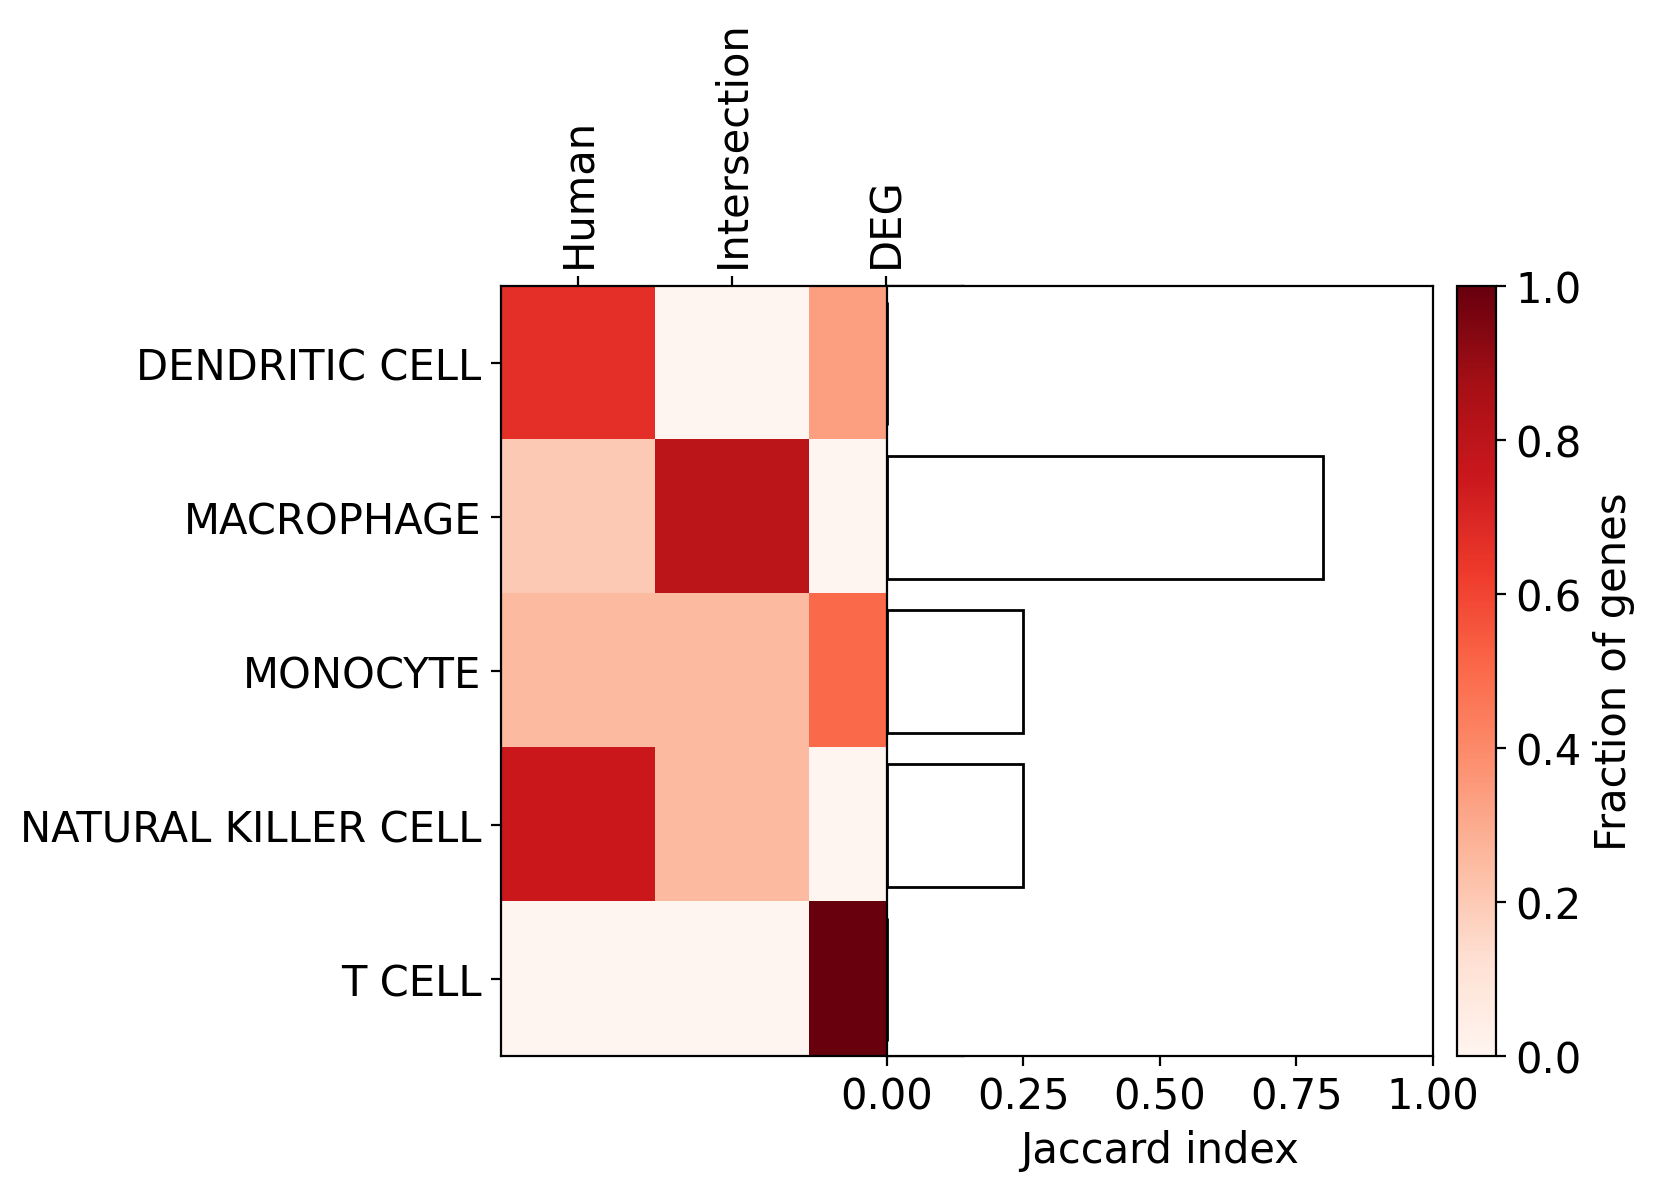

In [212]:
fig, axs = plt.subplots(figsize=(7, 5), ncols=2)
fig.subplots_adjust(hspace=0, wspace=-0.25)

ax = axs[0]
xlabels = ["Human", "Intersection", "DEG"]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]

cax = ax.imshow(eye, cmap="Reds", vmin=0, vmax=1)

ax.set(**{
    "xticks": np.arange(len(xlabels)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": xlabels,
    "yticklabels": hmnct,
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')  # Set the label position at the top

ax = axs[1]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])
jac = jac[::-1]

ax.barh(np.arange(len(hmnct)), jac, edgecolor="black", facecolor="white")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": [],
    "xlabel": "Jaccard index",
    # "title": "Jaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Fraction of genes")

plt.show()


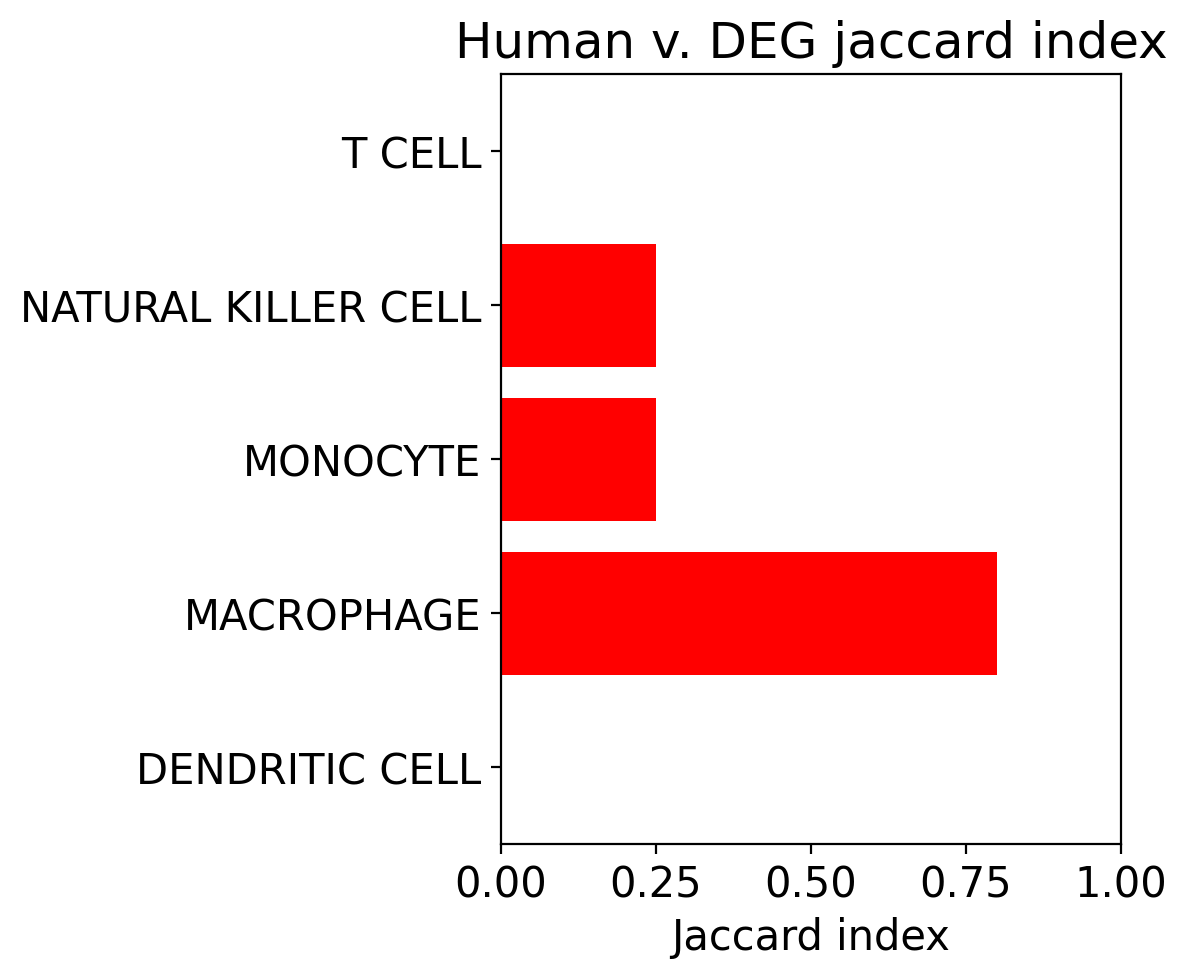

In [213]:
fig, ax = plt.subplots(figsize=(4, 5))

eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])

ax.barh(np.arange(len(hmnct)), jac, color="red")
ax.set(**{
    "yticks": np.arange(len(hmnct)),
    "yticklabels": hmnct,
    "xlabel": "Jaccard index",
    "title": "Human v. DEG jaccard index",
    "xlim": (0,1),
    "ylim": (-0.5, len(hmnct)-0.5)
})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.show()


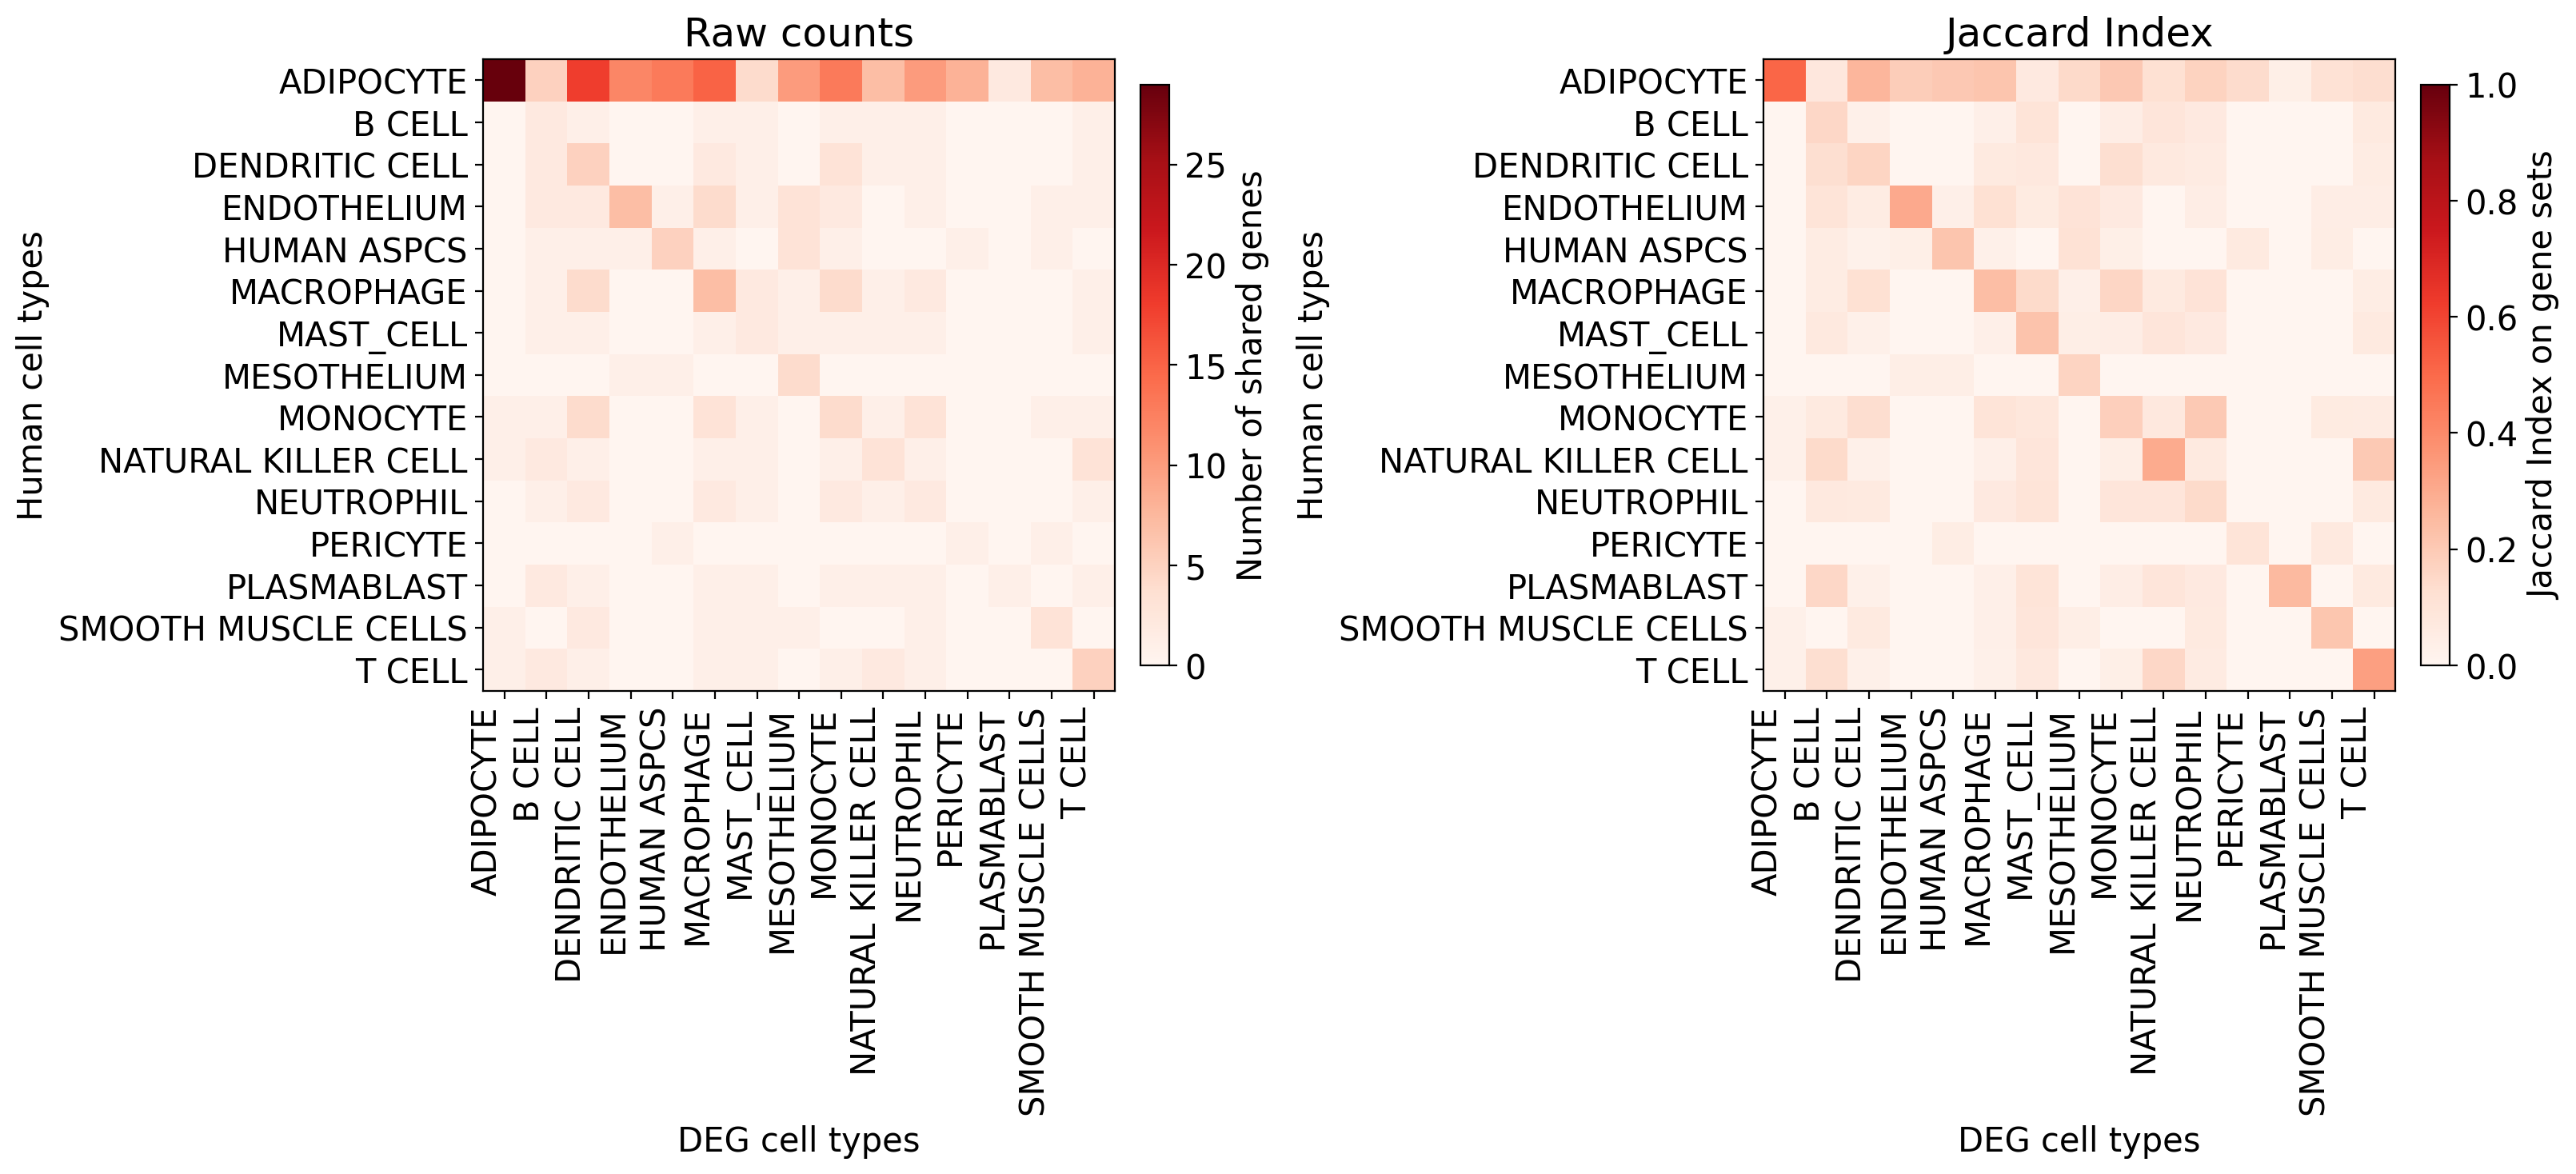

In [154]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds", vmin=0, vmax=1)
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


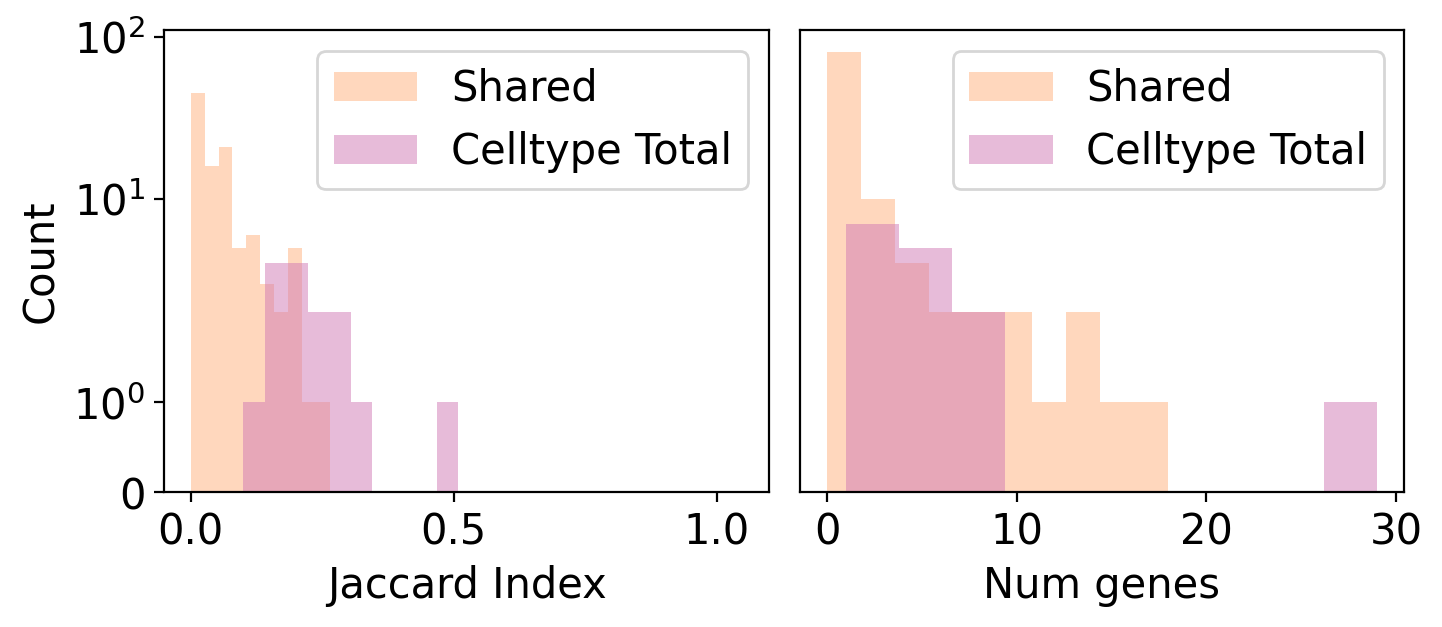

In [155]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

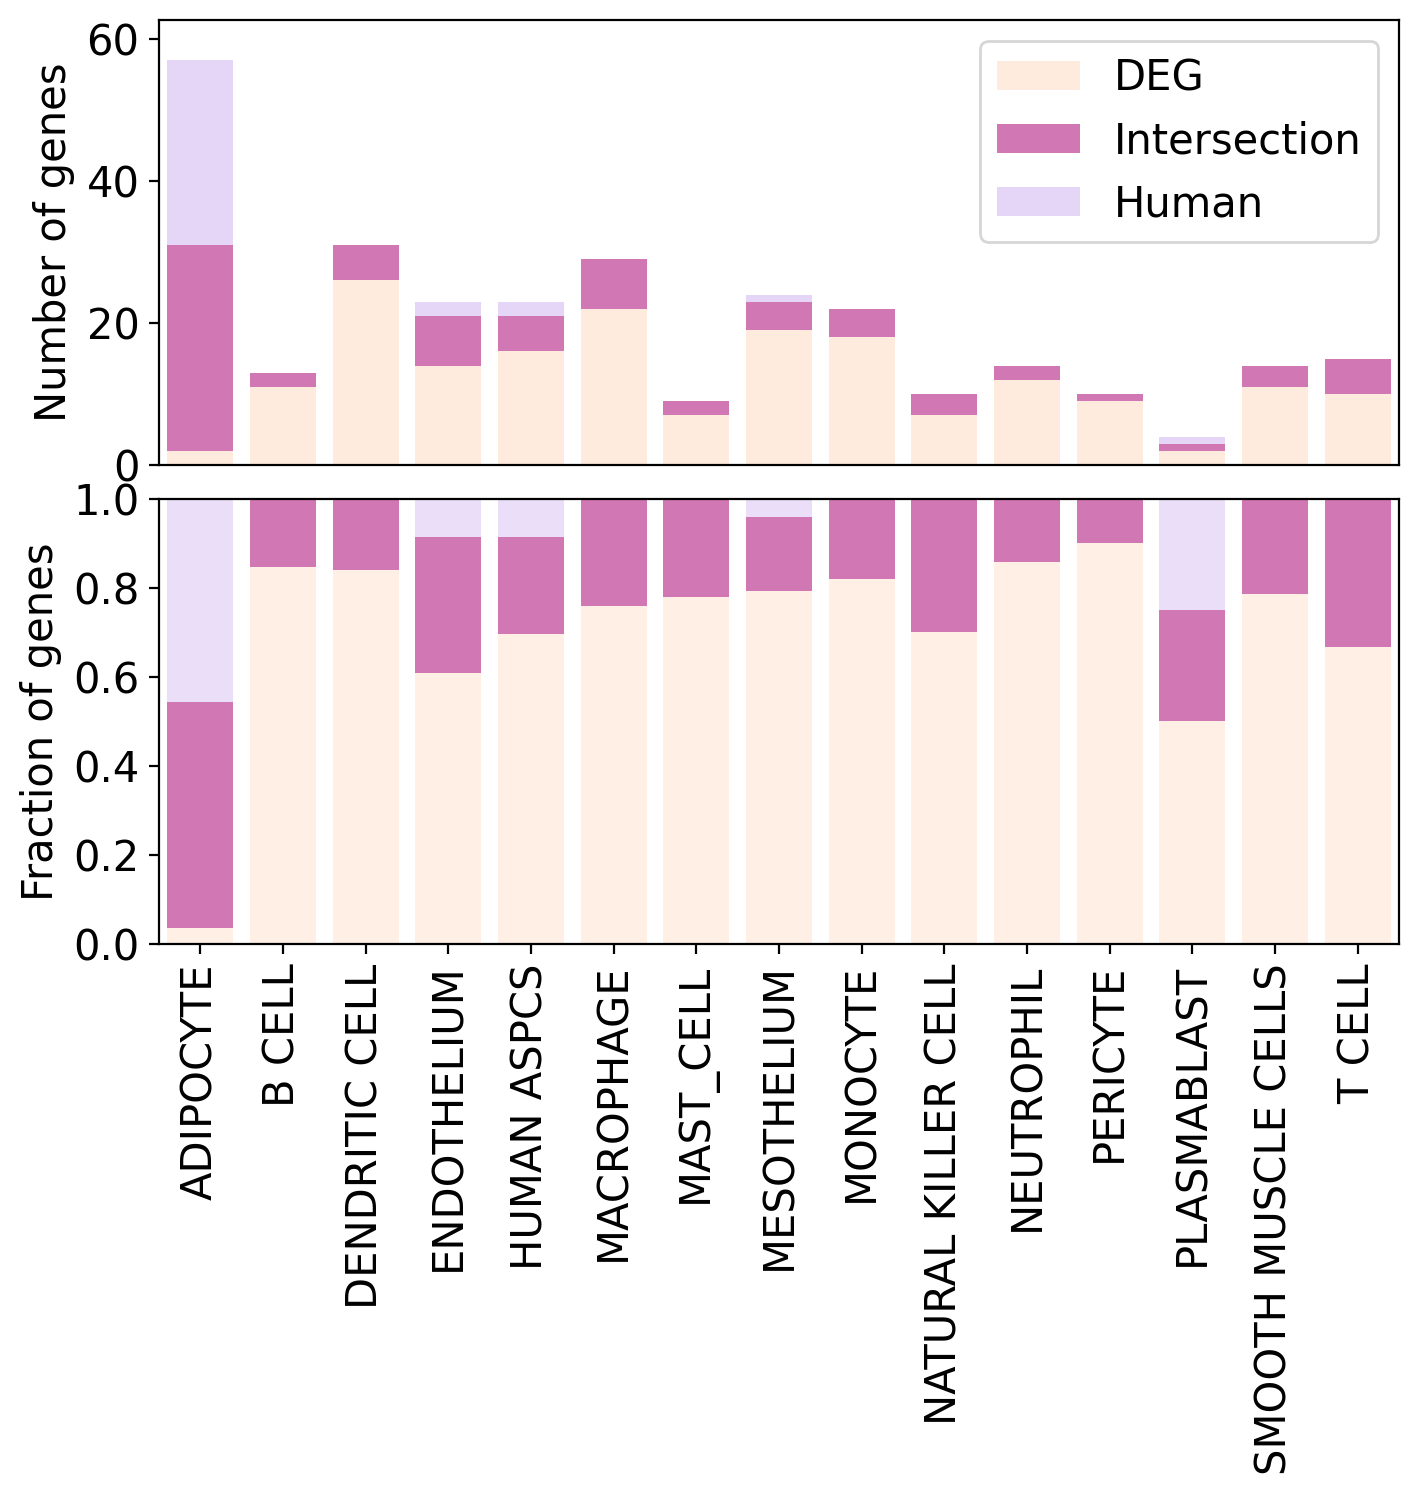

In [160]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'Human')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'Human')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()


# DEG against itself

In [161]:
(mtx, norm_mtx, _, degct) = ctg_metric(deg, deg, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

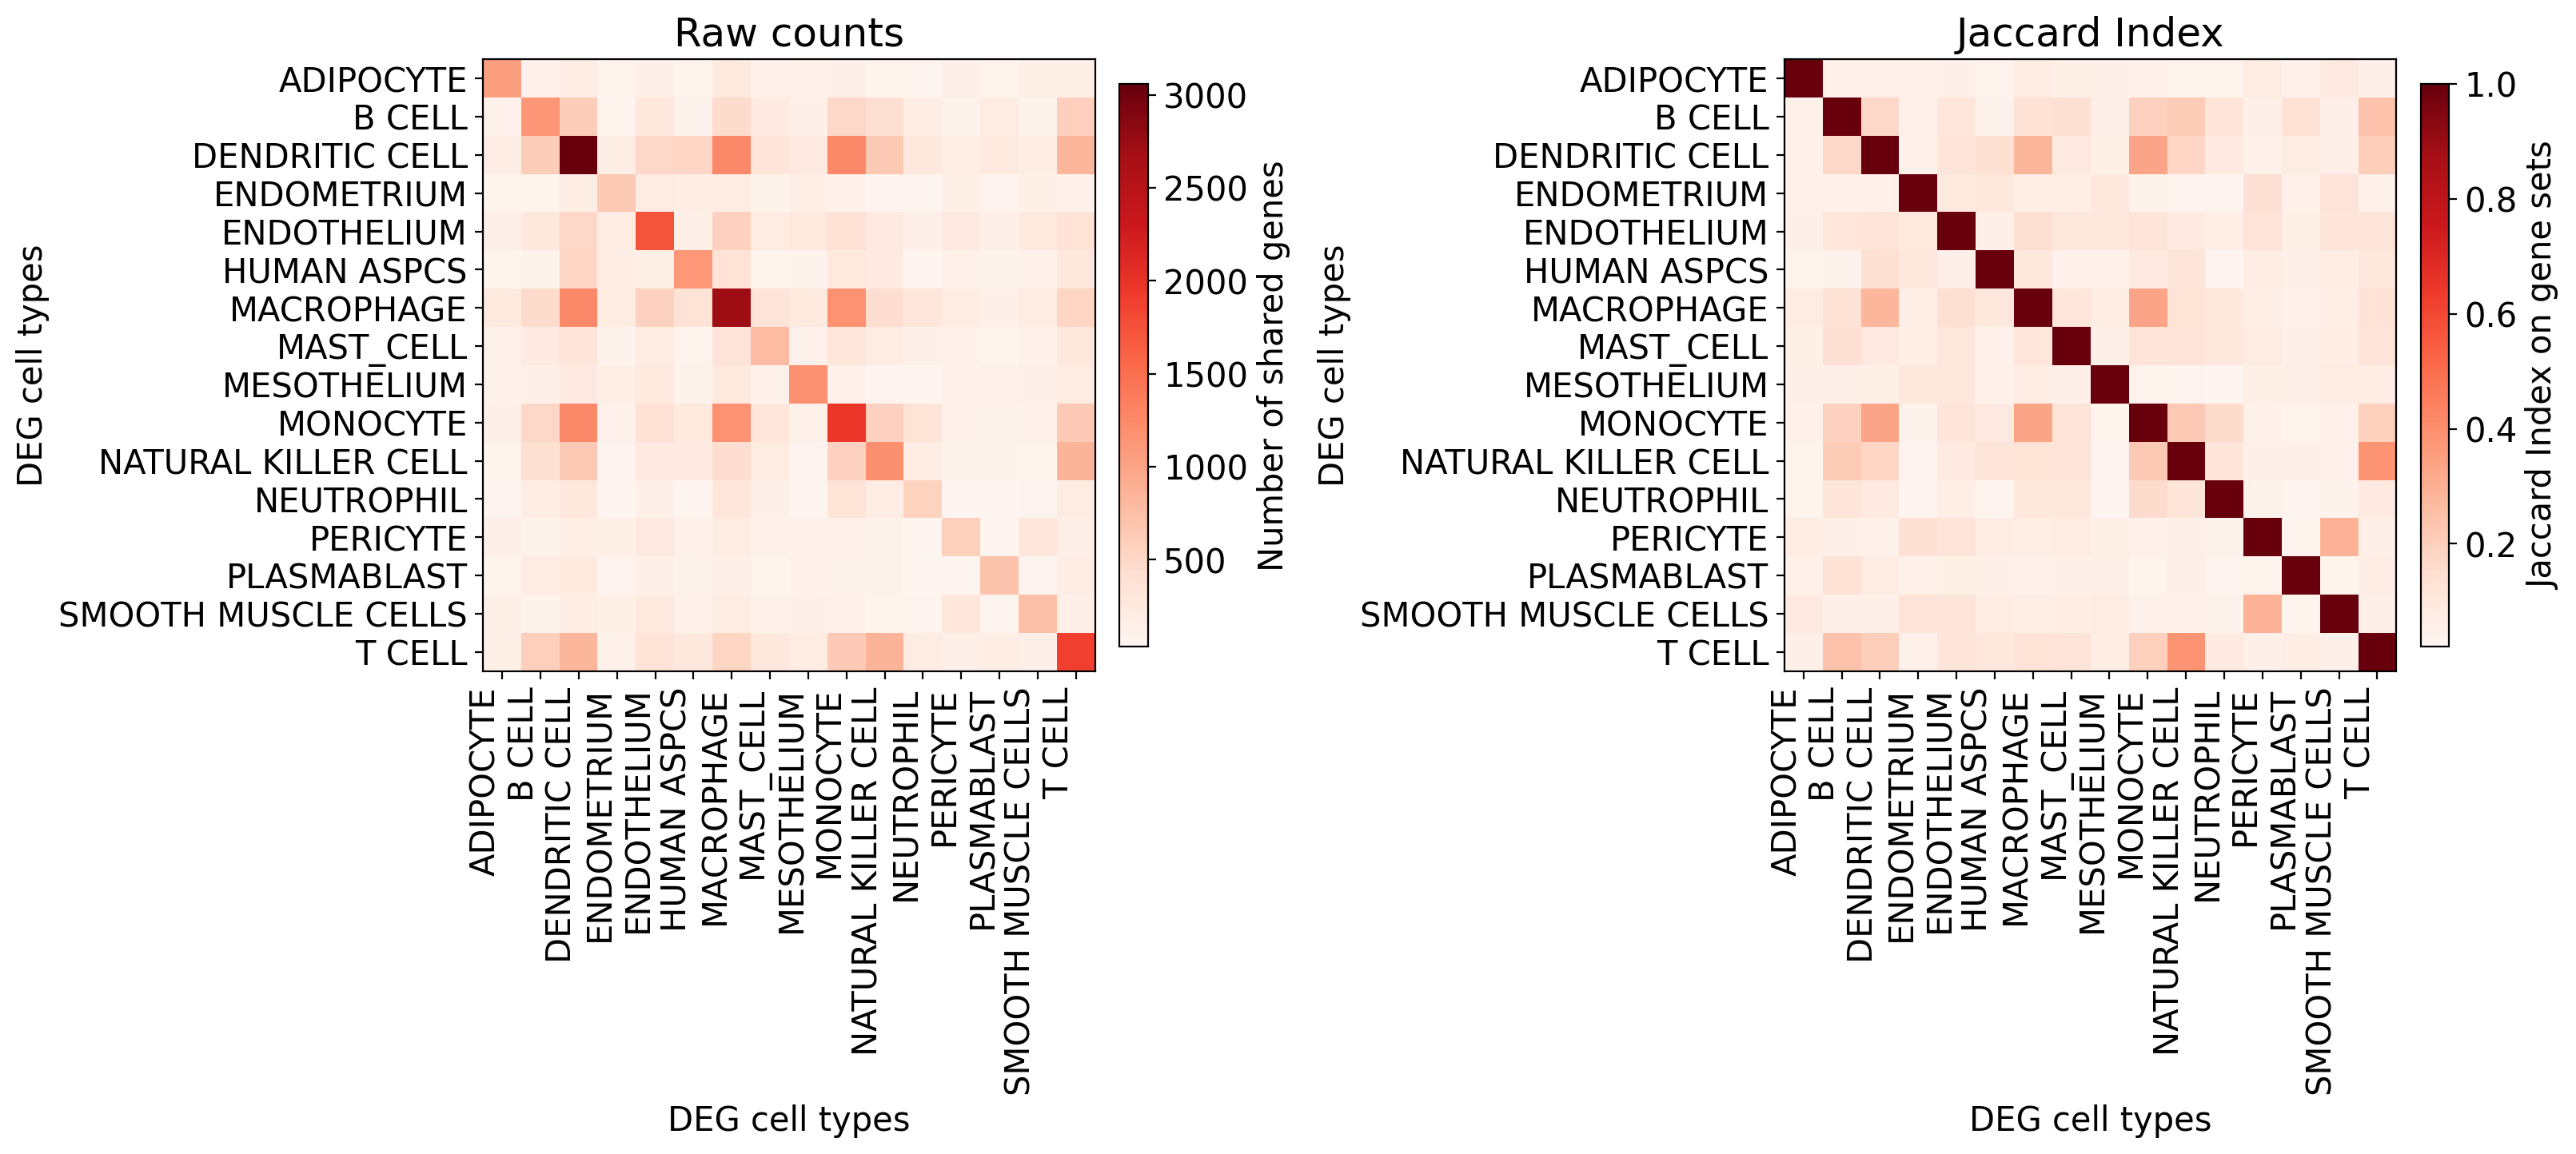

In [162]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "DEG cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(degct)),
    "xticklabels": degct,
    "yticklabels": degct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "DEG cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(degct)),
    "xticklabels": degct,
    "yticklabels": degct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


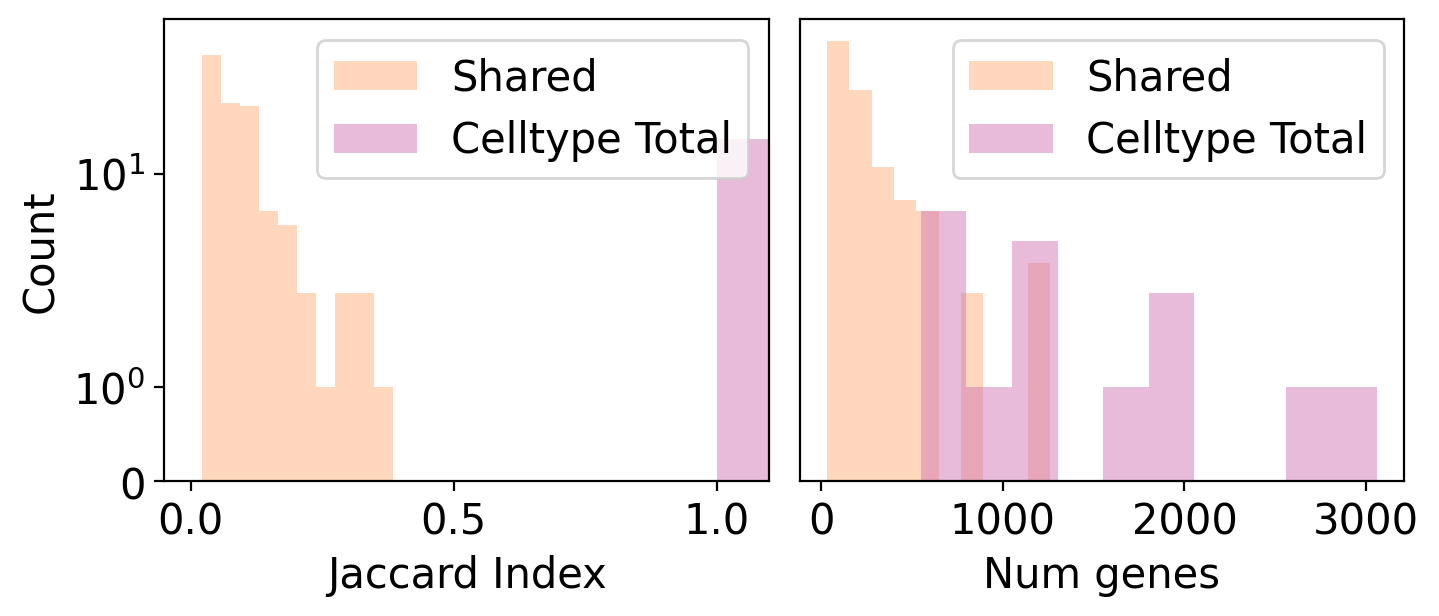

In [163]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

# Human against itself

In [164]:
(mtx, norm_mtx, hmnct, _) = ctg_metric(hmn, hmn, gene_col = "feature_identifier", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

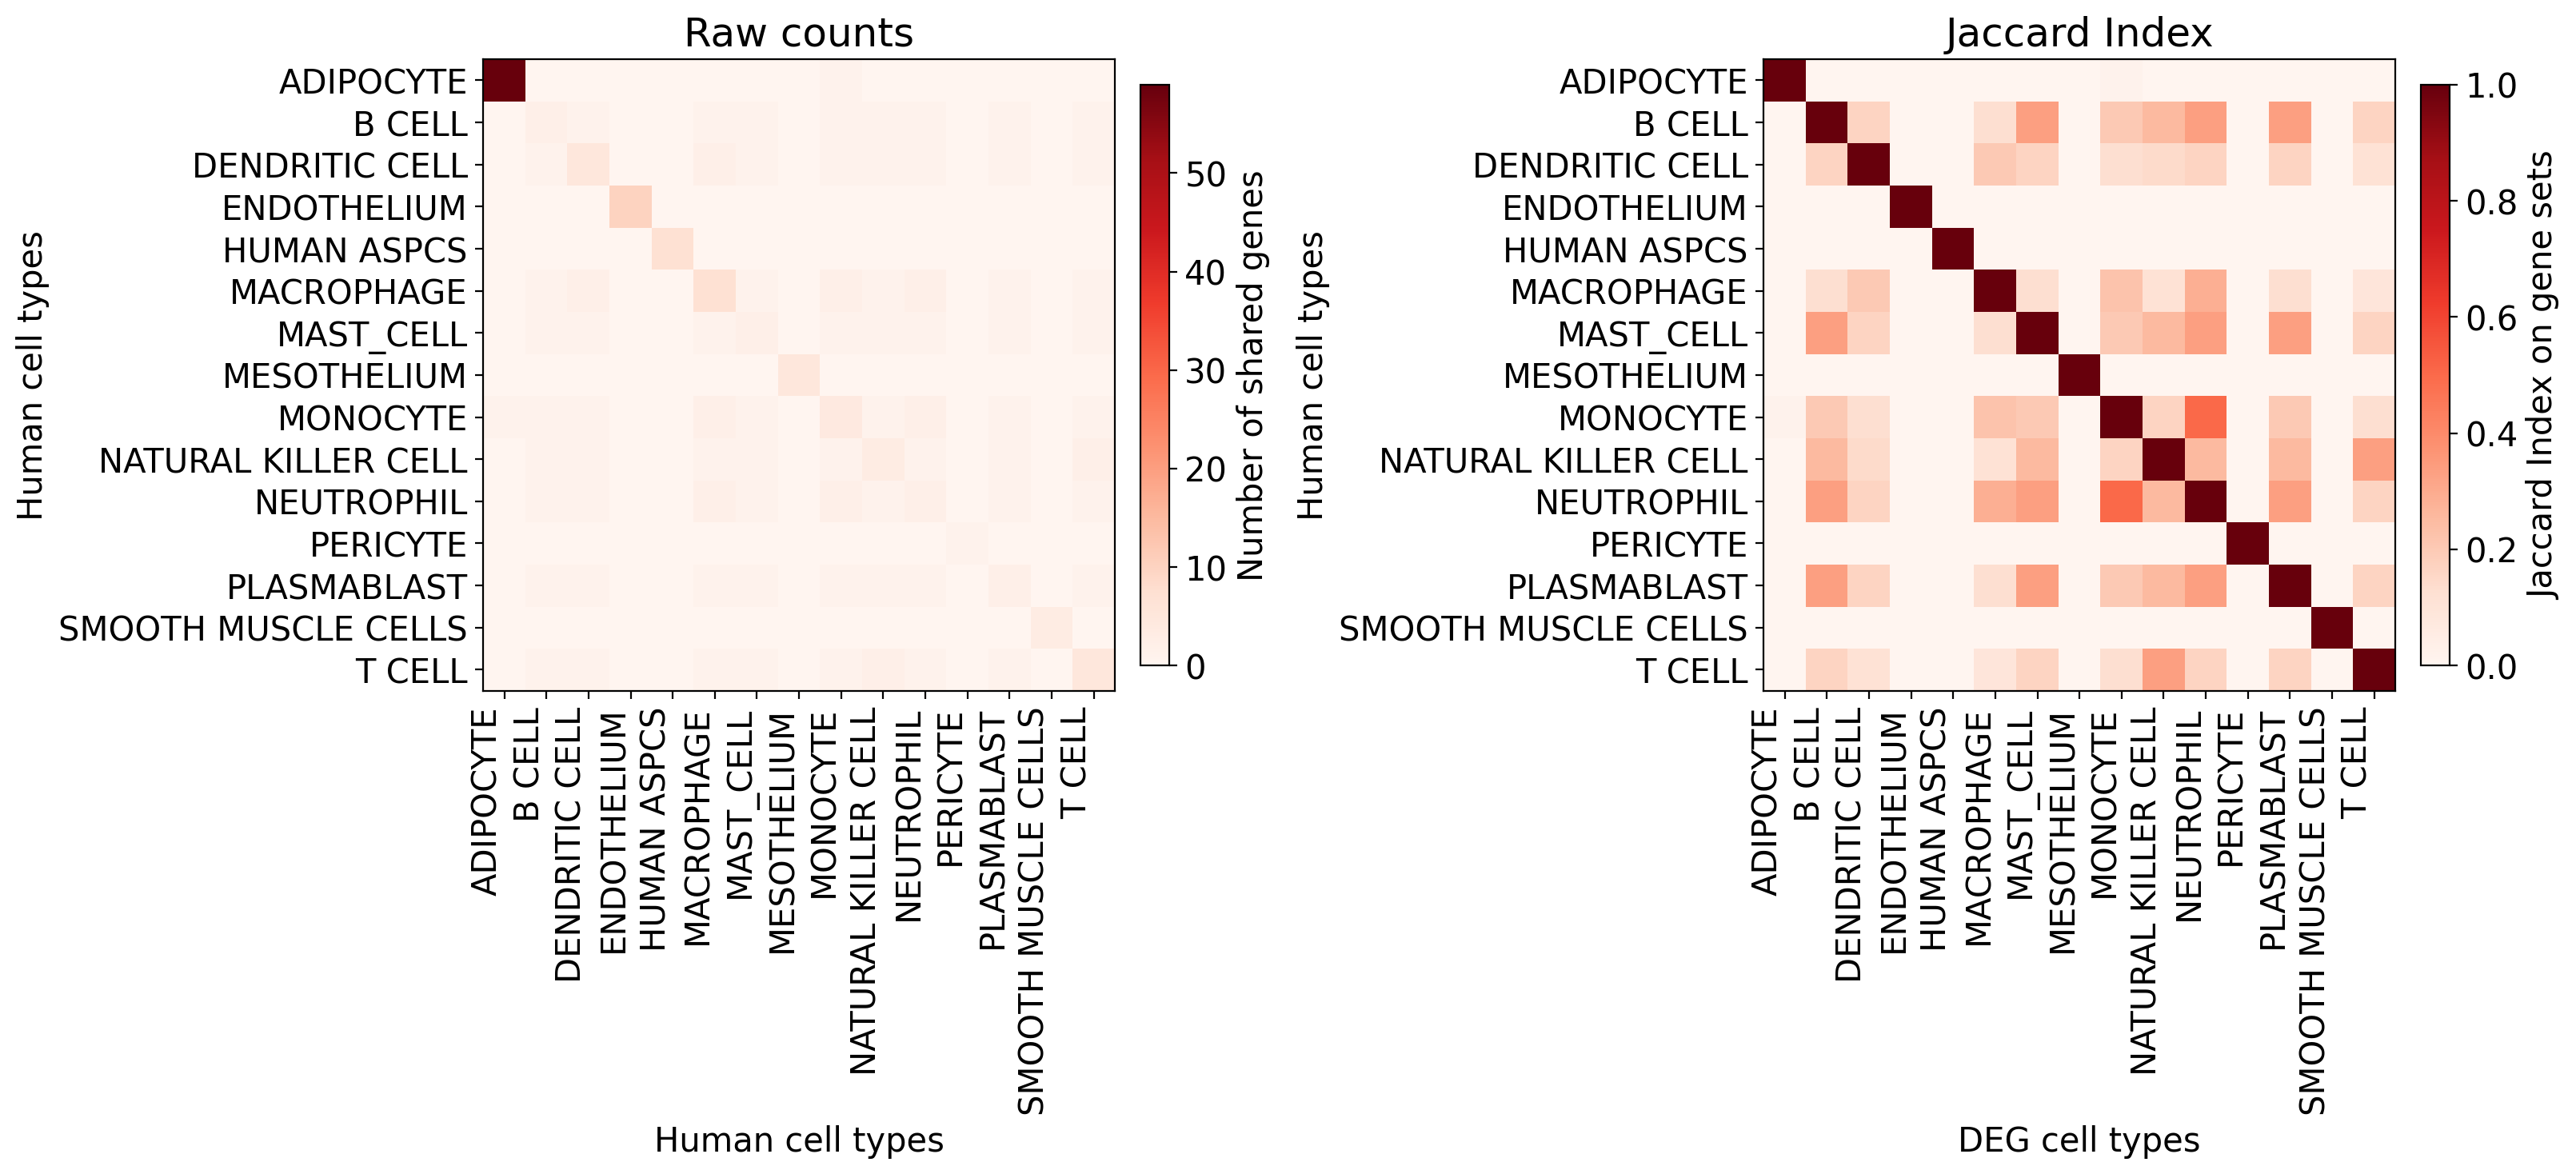

In [165]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, constrained_layout=True)

ax = axs[0]
x = mtx[:,:,1] 
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "Human cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(hmnct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": hmnct,
    "yticklabels": hmnct,
    "title": "Raw counts"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")

ax = axs[1]
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(hmnct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": hmnct,
    "yticklabels": hmnct,
    "title": "Jaccard Index"    
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard Index on gene sets")
plt.show()


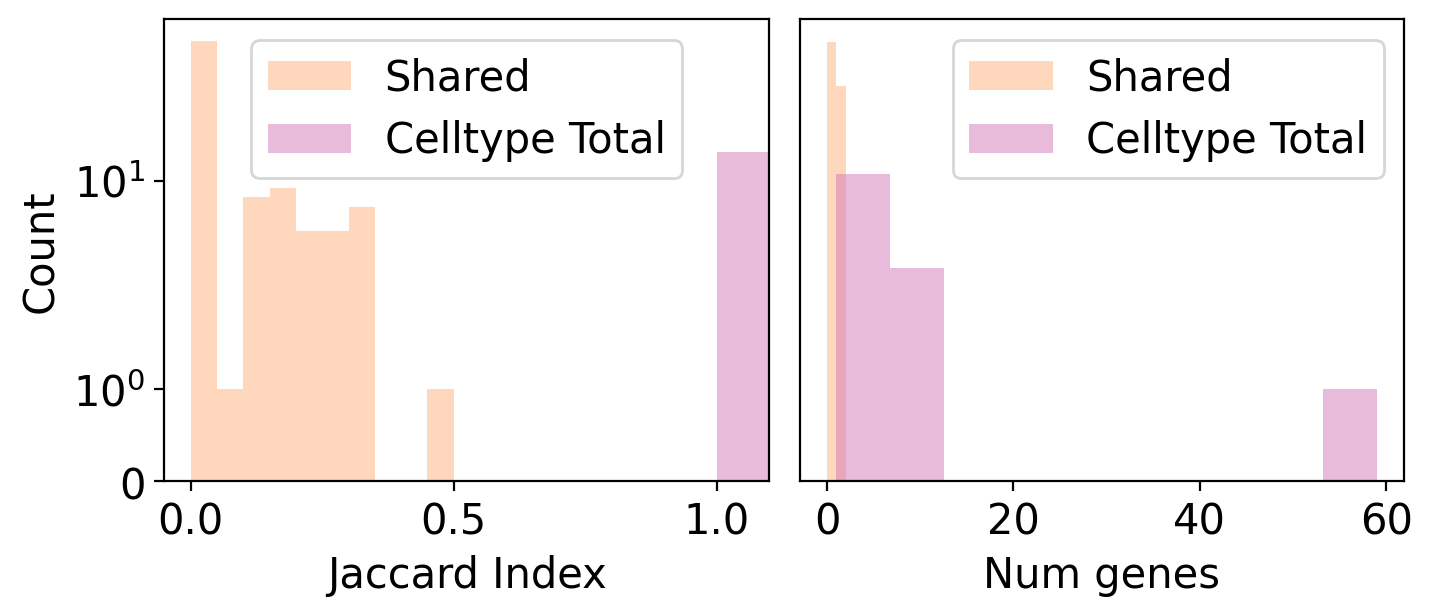

In [166]:
fig, axs = plt.subplots(figsize=(8, 3), ncols=2)
fig.subplots_adjust(hspace=0.5, wspace=0.05)
ax = axs[0]

x = mtx[:,:,1] / (mtx.sum(axis=2))
nonc = "#FFB07C"
yesc = "#D178B4"
non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 10, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Count",
    "xlim": (-.05, 1.1),
    "yscale": "symlog"
})
ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = mtx[:,:,1]

non = x[np.triu_indices(x.shape[0], k=1)]
yes = np.diag(x)

ax.hist(non, bins = 2, alpha=0.5, label="Shared", color=nonc)
ax.hist(yes, bins = 10, alpha=0.5, label="Celltype Total", color=yesc)

ax.set(**{
    "xlabel": "Num genes",
    # "ylabel": "Count",
    # "yticks": [],
    # "yticklabels": [],
    "yscale": "symlog"
})
ax.yaxis.set_visible(False)
ax.legend()


plt.show()

## Ternary Plots

In [167]:
norm_mtx.shape

(15, 15, 3)

In [168]:
tmp = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
l = tmp[:,0]
x = tmp[:,1]
r = tmp[:,2]

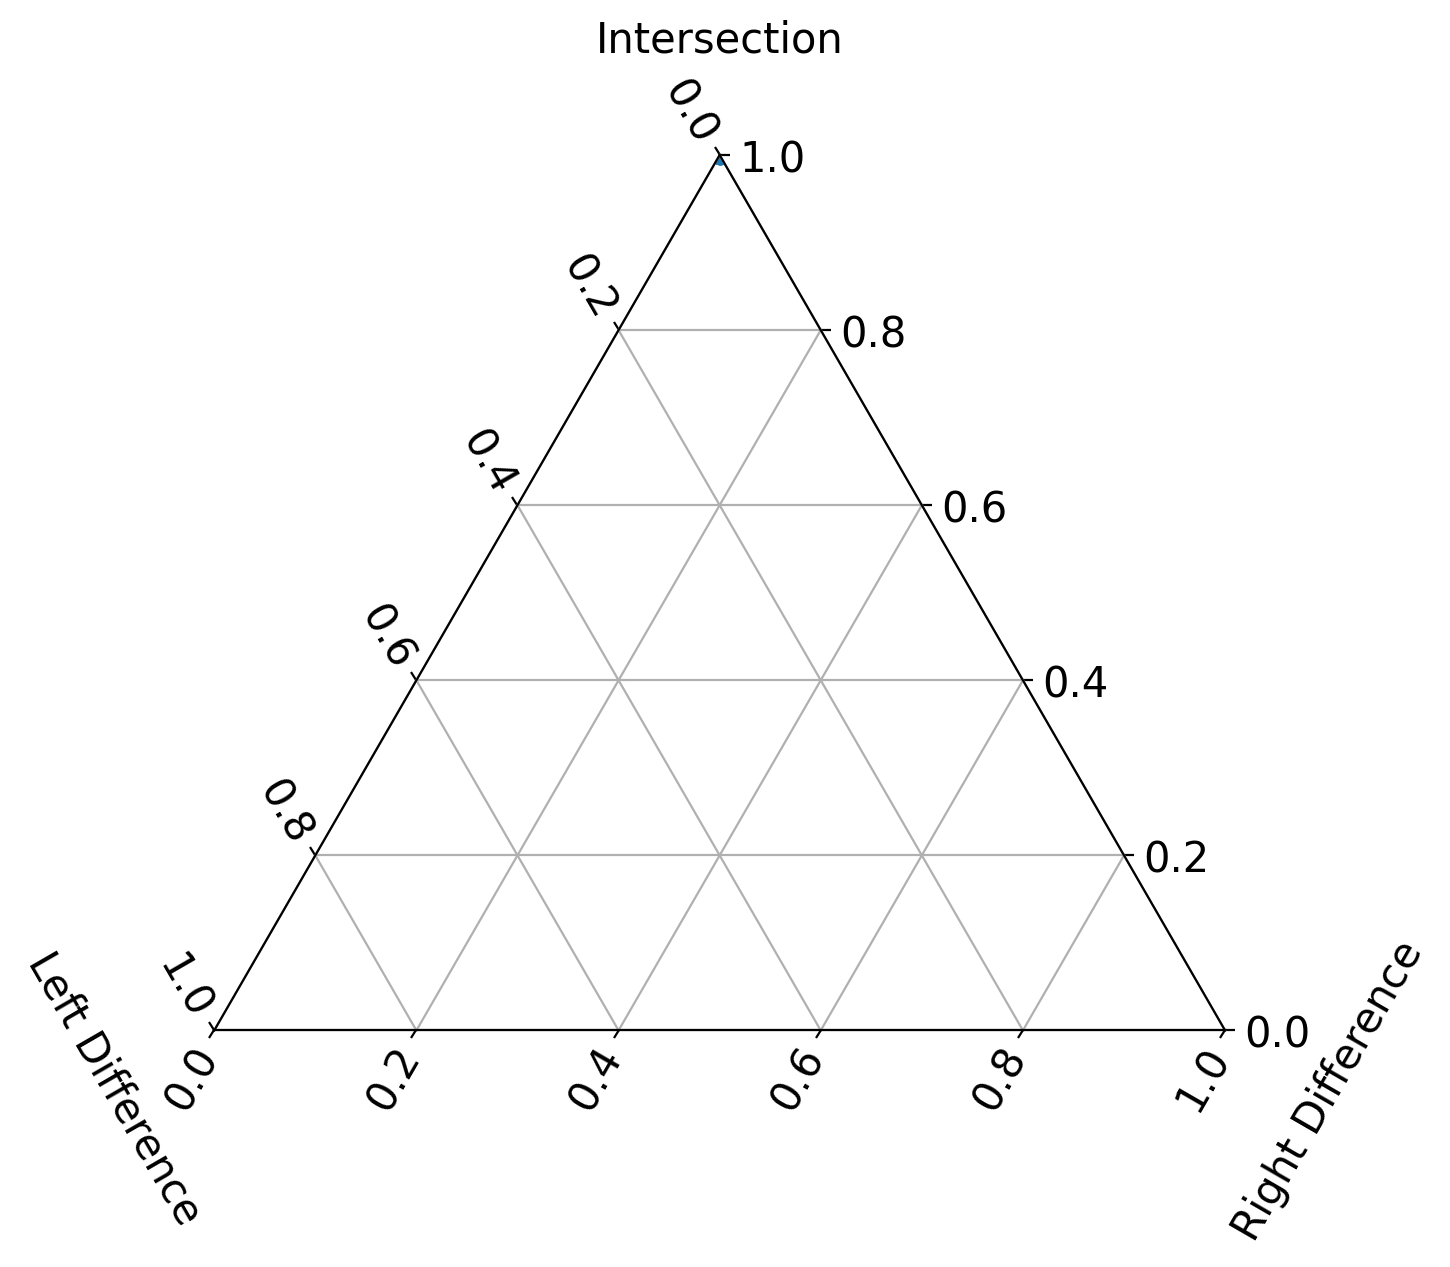

In [95]:
fig = plt.figure(figsize=(15, 15))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
pc = ax.scatter(x, l, r, alpha = 0.6, label = f"") # top, left, right

ax.grid(visible=  True, axis = 'both')

ax.set_tlabel('Intersection')
ax.set_llabel('Left Difference')
ax.set_rlabel('Right Difference')

#ax.legend(title = "Gene Expression Set Operations with Same Cell Type Control", fontsize = 'small', bbox_to_anchor=(0, 1, 0, .102))

plt.show()